In [21]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc, ConfusionMatrixDisplay

In [22]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m'

def colored_text(color, txt):
    return color + str(txt) + RESET

In [23]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_vehicules = []

for year in years:
    df_vehicules_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"vehicules-{year}.csv"), encoding="utf-8", sep = ";")
    df_vehicules.append(df_vehicules_year)

df_vehicules = pandas.concat(df_vehicules)
df_vehicules

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,NaN
1,201900000001,138 306 525,A01,2,17,1,0,3,11,1,NaN
2,201900000002,138 306 523,A01,1,7,4,0,1,0,1,NaN
3,201900000003,138 306 520,A01,1,7,0,2,1,2,1,NaN
4,201900000003,138 306 521,B01,1,7,1,0,4,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
92673,202400054401,155 686 119,Y01,1,60,1,2,7,0,5,NaN
92674,202400054401,155 686 120,A01,1,33,1,2,1,1,1,NaN
92675,202400054402,155 686 118,A01,1,10,0,2,1,2,1,NaN
92676,202400054402,155 686 121,B01,1,7,0,2,4,2,1,NaN


In [24]:
# correcting errors from the foreign key that is going to be used to link to another set of tables
df_vehicules["id_vehicule"] = (
    df_vehicules["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [25]:
df_vehicules[["Num_Acc", "id_vehicule"]].duplicated().sum()

np.int64(0)

In [26]:
# checking the proportion of empty values
df_vehicules.replace(-1, pandas.NA, inplace=True)

for col in df_vehicules.columns:
    prop = df_vehicules[col].isna().sum() / len(df_vehicules)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For num_veh proportion missing: 0.00%
For senc proportion missing: 0.26%
For catv proportion missing: 0.00%
For obs proportion missing: 0.04%
For obsm proportion missing: 0.05%
For choc proportion missing: 0.05%
For manv proportion missing: 0.04%
For motor proportion missing: 0.22%
For occutc proportion missing: 99.13%


In [27]:
# First we are dropping features that we are not going to use: "num_veh" as we will use "id_vehicule" instead
# and "occutc", which is the number of occupants in public transport, 
# this feature is almost always missing, so we are not going to be able to use it
df_vehicules.drop(columns = ['num_veh', 'occutc'], inplace = True)

In [28]:
# for others missing values, we have decided to fill them with the most frequent in the corresponding category
imputer_obs = SimpleImputer(strategy="most_frequent")
cat_small_na = df_vehicules.columns[(df_vehicules.isna().sum() > 0) & (df_vehicules.isna().sum() < 5000)]
print("Column names that are going to be filled :", cat_small_na)
df_vehicules[cat_small_na]= df_vehicules[cat_small_na].replace({pandas.NA: np.nan})
df_vehicules[cat_small_na] = imputer_obs.fit_transform(df_vehicules[cat_small_na])

Column names that are going to be filled : Index(['senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor'], dtype='str')


In [29]:
# converting the type of integer feature values to the correct type
cols_small_int = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor',"senc"]
df_vehicules[cols_small_int] = df_vehicules[cols_small_int].astype("int64")

In [30]:
# defining features by type
categorical_features = cols_small_int[:]
numerical_features = []
features = categorical_features + numerical_features

In [31]:
# We need to load usagers, because it contains our target column, which is needed for further analysis
df_usagers = pandas.read_csv("data_clean/df_usagers_clean.csv")

df_vehicules_with_target = df_usagers[['Num_Acc', 'id_vehicule', 'grav_bin']].merge(df_vehicules, on=['Num_Acc', 'id_vehicule'], how='left')

target = "grav_bin"

In [32]:
# in case there was some missing (Num_Acc, id_vehicule) key pair in "vehicules" set of tables
df_vehicules_with_target = df_vehicules_with_target.dropna()

In [33]:
# definign specific dataframe for feature analysis
df_vehicules_analyse = df_vehicules_with_target.copy() 

mapping = {
    0: "Undeterminable",
    1: "Bicycle",
    2: "Moped <50cc",
    3: "Microcar (enclosed motorized quadricycle)",
    4: "Unused reference since 2006 (registered scooter)",
    5: "Unused reference since 2006 (motorcycle)",
    6: "Unused reference since 2006 (sidecar)",
    7: "Passenger car only",
    8: "Unused reference since 2006 (car + caravan)",
    9: "Unused reference since 2006 (car + trailer)",
    10: "Light utility vehicle only 1.5T <= GVWR <= 3.5T with or without trailer",
    11: "Unused reference since 2006 (LUV (10) + caravan)",
    12: "Unused reference since 2006 (LUV (10) + trailer)",
    13: "Heavy goods vehicle only 3.5T < GVWR <= 7.5T",
    14: "Heavy goods vehicle only > 7.5T",
    15: "Heavy goods vehicle > 3.5T + trailer",
    16: "Road tractor only",
    17: "Road tractor + semi-trailer",
    18: "Unused reference since 2006 (public transport)",
    19: "Unused reference since 2006 (tramway)",
    20: "Special vehicle",
    21: "Agricultural tractor",
    30: "Scooter < 50cc",
    31: "Motorcycle > 50cc and <= 125cc",
    32: "Scooter > 50cc and <= 125cc",
    33: "Motorcycle > 125cc",
    34: "Scooter > 125cc",
    35: "Light quad <= 50cc (non-enclosed motorized quadricycle)",
    36: "Heavy quad > 50cc (non-enclosed motorized quadricycle)",
    37: "Bus",
    38: "Coach",
    39: "Train",
    40: "Tramway",
    41: "3-wheel motor vehicle <= 50cc",
    42: "3-wheel motor vehicle > 50cc <= 125cc",
    43: "3-wheel motor vehicle > 125cc",
    50: "Motorized personal transport device",
    60: "Non-motorized personal transport device",
    80: "Electric-assisted bicycle",
    99: "Other vehicle"
}

df_vehicules_analyse["catv"] = df_vehicules_analyse["catv"].replace(mapping)

mapping = {
    0: "Not applicable",
    1: "Parked vehicle",
    2: "Tree",
    3: "Metal guardrail",
    4: "Concrete guardrail",
    5: "Other guardrail",
    6: "Building, wall, bridge pier",
    7: "Vertical road sign support or emergency call post",
    8: "Pole",
    9: "Street furniture",
    10: "Parapet",
    11: "Island, refuge, bollard",
    12: "Curb",
    13: "Ditch, embankment, rock wall",
    14: "Other fixed obstacle on roadway",
    15: "Other fixed obstacle on sidewalk or shoulder",
    16: "Run-off-road without obstacle",
    17: "Culvert – culvert head"
}

df_vehicules_analyse["obs"] = df_vehicules_analyse["obs"].replace(mapping)

mapping = {
    0: "None",
    1: "Pedestrian",
    2: "Vehicle",
    4: "Rail vehicle",
    5: "Domestic animal",
    6: "Wild animal",
    9: "Other"
}

df_vehicules_analyse["obsm"] = df_vehicules_analyse["obsm"].replace(mapping)

mapping = {
    0: "None",
    1: "Front",
    2: "Front right",
    3: "Front left",
    4: "Rear",
    5: "Rear right",
    6: "Rear left",
    7: "Right side",
    8: "Left side",
    9: "Multiple impacts (rollovers)"
}

df_vehicules_analyse["choc"] = df_vehicules_analyse["choc"].replace(mapping)

mapping = {
    0: "Unknown",
    1: "No change of direction",
    2: "Same direction, same lane",
    3: "Between two lanes",
    4: "Reversing",
    5: "Wrong-way driving",
    6: "Crossing the central reservation",
    7: "In the bus lane, same direction",
    8: "In the bus lane, opposite direction",
    9: "Merging",
    10: "Making a U-turn on the roadway",
    11: "Left (changing lane)",
    12: "Right (changing lane)",
    13: "Left (swerving)",
    14: "Right (swerving)",
    15: "Left (turning)",
    16: "Right (turning)",
    17: "Left (overtaking)",
    18: "Right (overtaking)",
    19: "Crossing the roadway",
    20: "Parking maneuver",
    21: "Evasive maneuver",
    22: "Door opening",
    23: "Stopped (excluding parking)",
    24: "Parked (with occupants)",
    25: "Driving on sidewalk",
    26: "Other maneuvers"
}

df_vehicules_analyse["manv"] = df_vehicules_analyse["manv"].replace(mapping)

mapping = {
    0: "Unknown",
    1: "Hydrocarbons",
    2: "Hybrid electric",
    3: "Electric",
    4: "Hydrogen",
    5: "Human-powered",
    6: "Other"
}

df_vehicules_analyse["motor"] = df_vehicules_analyse["motor"].replace(mapping)

mapping = {
    0: "Unknown",
    1: "Increasing PK or PR or postal address number",
    2: "Decreasing PK or PR or postal address number",
    3: "No reference point"
}

df_vehicules_analyse["senc"] = df_vehicules_analyse["senc"].replace(mapping)

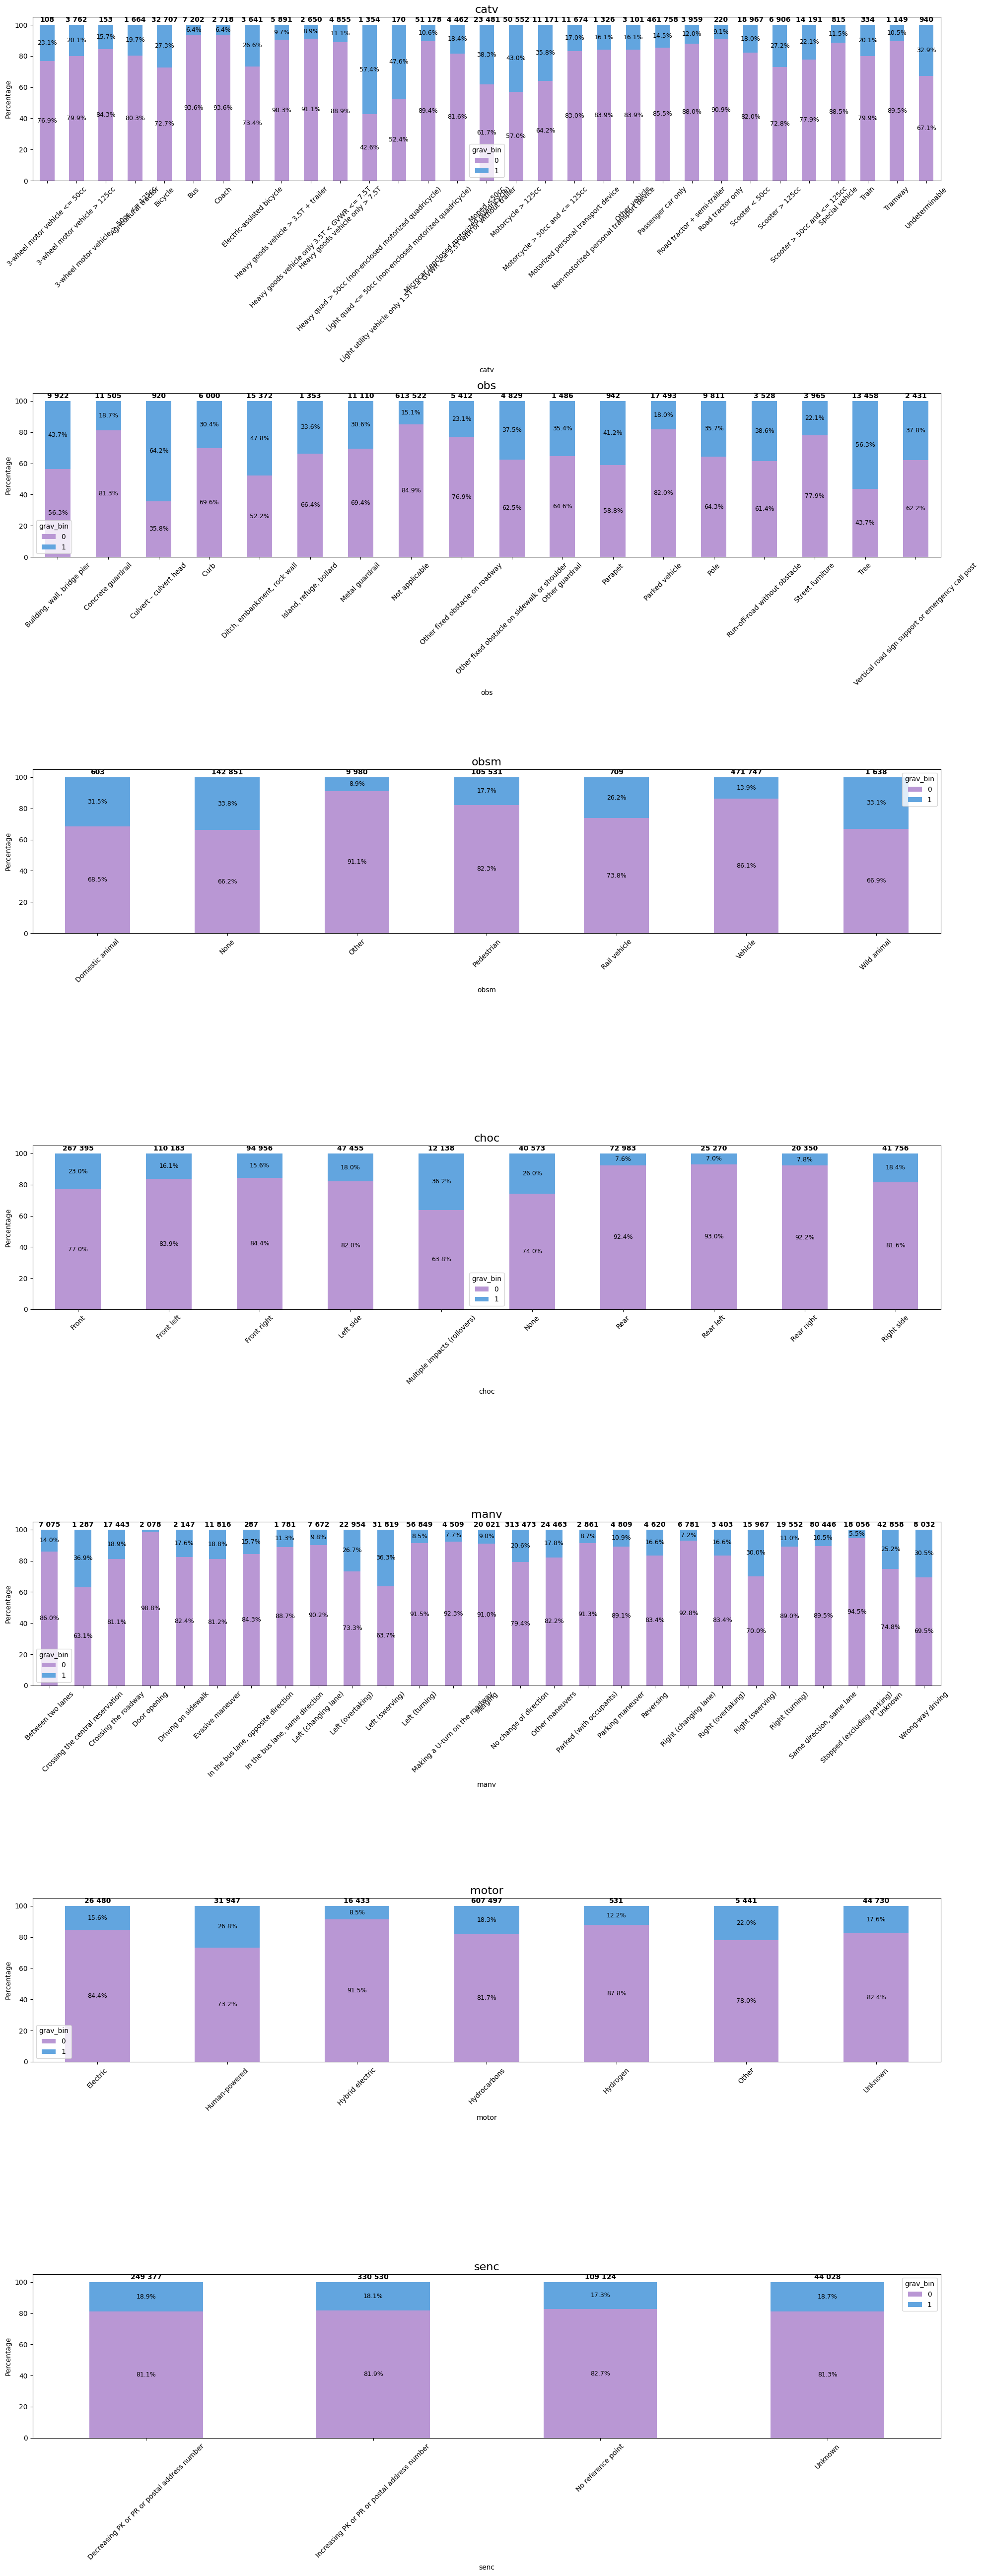

In [34]:
# plotting the counts per class and the proportions of target labels
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_vehicules_analyse[feature],
        df_vehicules_analyse[target],
        normalize="index"
    ) * 100

    counts = df_vehicules_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [35]:
def latex_escape_category(x):
    x = str(x)
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

for feature in features:
    counts = df_vehicules_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100
    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)

        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

print("\n".join(output_lines))

\texttt{catv} & 3-wheel motor vehicle $\le$ 50cc & 108 & 76.9 & 23.1 \\
 & 3-wheel motor vehicle $>$ 125cc & 3 762 & 79.9 & 20.1 \\
 & 3-wheel motor vehicle $>$ 50cc $\le$ 125cc & 153 & 84.3 & 15.7 \\
 & Agricultural tractor & 1 664 & 80.3 & 19.7 \\
 & Bicycle & 32 707 & 72.7 & 27.3 \\
 & Bus & 7 202 & 93.6 & 6.4 \\
 & Coach & 2 718 & 93.6 & 6.4 \\
 & Electric-assisted bicycle & 3 641 & 73.4 & 26.6 \\
 & Heavy goods vehicle $>$ 3.5T + trailer & 5 891 & 90.3 & 9.7 \\
 & Heavy goods vehicle only 3.5T $<$ GVWR $\le$ 7.5T & 2 650 & 91.1 & 8.9 \\
 & Heavy goods vehicle only $>$ 7.5T & 4 855 & 88.9 & 11.1 \\
 & Heavy quad $>$ 50cc (non-enclosed motorized quadricycle) & 1 354 & 42.6 & 57.4 \\
 & Light quad $\le$ 50cc (non-enclosed motorized quadricycle) & 170 & 52.4 & 47.6 \\
 & Light utility vehicle only 1.5T $\le$ GVWR $\le$ 3.5T with or without trailer & 51 178 & 89.4 & 10.6 \\
 & Microcar (enclosed motorized quadricycle) & 4 462 & 81.6 & 18.4 \\
 & Moped $<$50cc & 23 481 & 61.7 & 38.3 \\


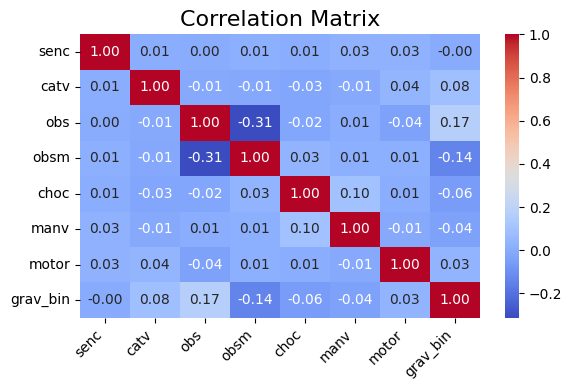

In [36]:
# correlation matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    df_vehicules_with_target[['senc', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'motor', 'grav_bin']].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("over_sampling", RandomOverSampler(random_state=20)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("under_sampling", RandomUnderSampler(random_state=20)),
        ("model", model)
    ])

print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (oversampling)"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (undersampling)"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

Model selection with cross-validation (oversampling)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.71      0.79    479081
           1       0.34      0.67      0.45    107366

    accuracy                           0.70    586447
   macro avg       0.62      0.69      0.62    586447
weighted avg       0.80      0.70      0.73    586447


 Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.72      0.80    479081
           1       0.34      0.65      0.45    107366

    accuracy                           0.71    586447
   macro avg       0.62      0.68      0.62    586447
weighted avg       0.80      0.71      0.74    586447


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.91      0.71      0.80    479081
           1       0.34      0.67      0.45    107366

    accuracy                           0.70    586447
   macro avg     

              precision    recall  f1-score   support

           0       0.90      0.71      0.80    119770
           1       0.34      0.66      0.45     26842

    accuracy                           0.70    146612
   macro avg       0.62      0.69      0.62    146612
weighted avg       0.80      0.70      0.73    146612



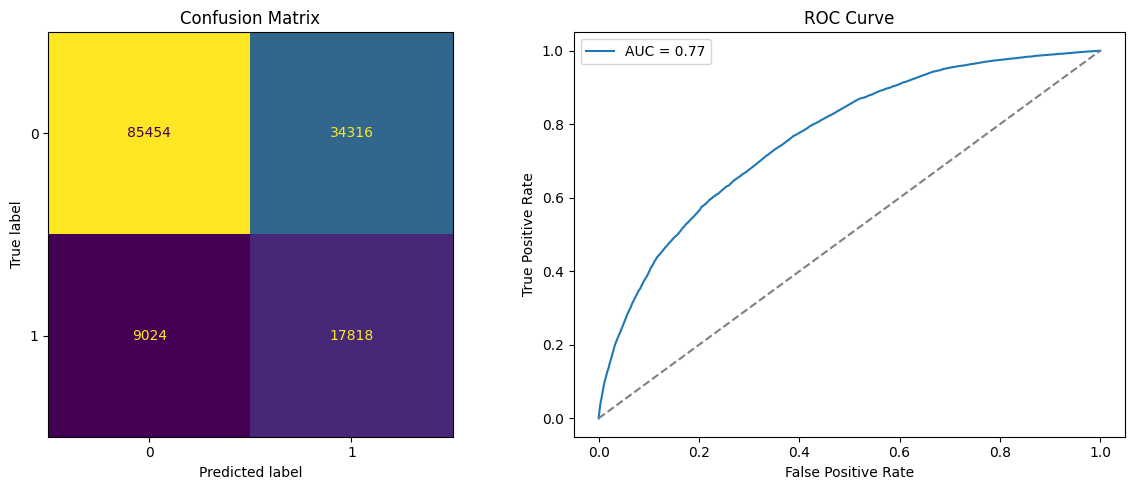

In [39]:
# Here also Gradient Boosting and undersampling have one of the best results according 
# to the trade-off bewteen precision and recall for the minority class
# so let's take this model

# Train and predict
model = pipelines_under["Gradient Boosting"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# Finally we are going to save the dataset cleaned
df_vehicules.to_csv("data_clean/df_vehicules_clean.csv", index=False)